# Customer Churn Analysis Using EDA

## Objective

- Import and explore the customer churn dataset  
- Perform initial data inspection and understand data structure  
- Clean the dataset by handling missing values and inconsistencies  
- Identify and remove duplicate records  
- Detect and treat outliers for accurate analysis  
- Perform Exploratory Data Analysis (EDA) to uncover patterns and trends  
- Solve real-world business problems using data insights  
- Extract meaningful insights to support data-driven decision making  

## Step 1 — Import Required Libraries

### Objective: 
Load all necessary Python libraries for data analysis, visualization, and Machine Learning.

### Insights:
- numpy and pandas handle numerical operations and dataframes
- matplotlib and seaborn provide visualization capabilities
- sklearn and xgboost power the Machine Learning pipeline
- warnings.filterwarnings("ignore") keeps output clean

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Step 2 — Load the Dataset

### Objective: 
Load the churn dataset and take an initial look at the raw data.

### Insights:
- Dataset contains telecom customer records with usage, billing, and service features
- Target column is Churn (Yes/No — binary classification)
- encoding=latin-1 handles any special characters in the CSV
- Always display the dataframe after loading to spot obvious issues immediately

In [2]:
df = pd.read_csv("churn.csv",encoding="latin-1")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Step 3 — Dataset Understanding

### Objective: 
Understand the structure, shape, data types, and statistical summary of the dataset.

### Insights:
- Dataset contains customer-level features like call duration, charges, customer service calls, and plan type
- Mix of numerical (int64, float64) and categorical (object) columns
- df.describe() reveals the distribution and scale of numerical features
- df.info() confirms data types and reveals implicit null indicators
- The target column Churn is binary — this is a Classification problem, not regression

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Step 4 — Data Cleaning

### Objective: 
Improve dataset quality by handling missing values, duplicates, and inconsistencies.

### Insights:
- Dataset has no missing values, but this should always be verified programmatically
- Duplicate records can cause model bias and overfitting — always check and remove
- Dropping duplicates reduced the dataset slightly but improved integrity
- Categorical columns need to be stripped of whitespace for consistency

## Missing Value Analysis

### Objective: 
- Identify and handle columns with missing data.

### Insights:
- No missing values were found in the churn dataset — a clean dataset is relatively rare
- Even with 0 nulls, document this finding explicitly — it's important for reproducibility
- If missing values existed: numerical columns → fill with median; categorical → fill with mode

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Duplicate Records Check

### Objective: 
Remove duplicate rows to prevent data leakage and model bias.

### Insights:
- Duplicates found and removed to improve data integrity
- Always check shape before and after to confirm how many rows were dropped

In [8]:
print("Duplicates before:",df.duplicated().sum())
df = df.drop_duplicates()
print("shape after droping duplicate records:",df.shape)

Duplicates before: 0
shape after droping duplicate records: (7043, 21)


## Cleaning Categorical Columns

### Objective: 
Standardize categorical values for consistent encoding and analysis.

### Insights:
- Columns like State, International plan, and Voice mail plan may have inconsistent casing or trailing spaces
- Lowercase + strip is a low-cost, high-value cleaning step
- Binary categorical columns (yes/no) should be verified for consistency before encoding

In [9]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].str.lower().str.strip()

print(df[cat_cols].nunique())

customerID          7043
gender                 2
Partner                2
Dependents             2
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
TotalCharges        6531
Churn                  2
dtype: int64


## Step 5 — Separate Numerical and Categorical Columns

### Objective: 
Identify and separate column types for type-appropriate processing.

### Insights:
- Numerical and categorical features require different preprocessing strategies
- Churn (the target) is excluded from the categorical feature set to avoid accidental encoding
- Clearly separating num_col and cat_col early improves code readability throughout the notebook

In [10]:
num_col = df.select_dtypes(include=["int64", "float64"]).columns
cat_col = df.select_dtypes(include=["object"]).columns

# Exclude target from feature columns
cat_features = cat_col.drop("Churn")

print("Numerical Columns:", list(num_col))
print("Categorical Columns:", list(cat_features))

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


## Step 6 — Outlier Analysis and Handling

### Objective: 
Identify and handle extreme values in numerical features that could distort model training.

### Analysis Insight:
- Features like Total day minutes, Total intl calls, and Customer service calls may have extreme outliers
- Boxplots are the standard visualization for outlier detection

### Handling Insight:
- IQR capping is preferred over removal — it preserves business context
- After capping, re-plot boxplots to confirm outlier reduction

<Axes: >

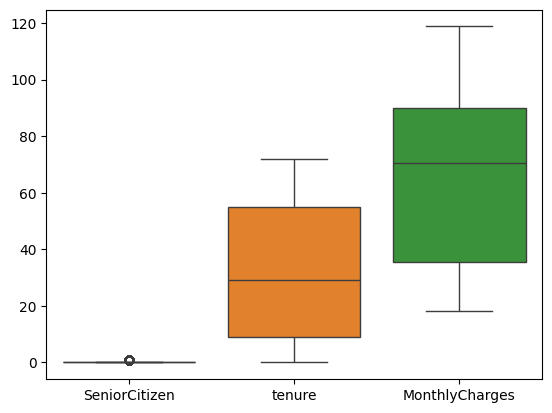

In [11]:
sns.boxplot(df)

In [12]:
# IQR Capping
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, np.where(df[col] > upper, upper, df[col]))

<Axes: >

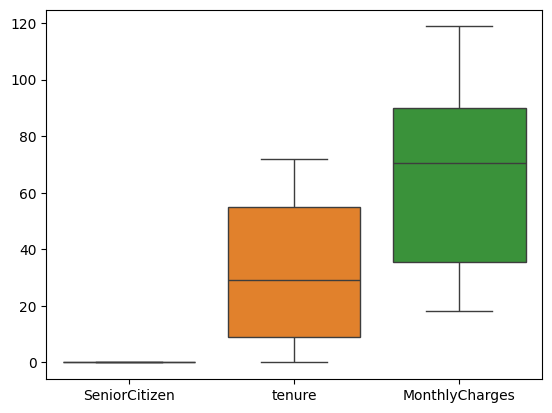

In [13]:
# After capping — re-visualize
sns.boxplot(df)

## Categorical Feature vs Churn

### Objective: 
- Analyze how categorical features relate to churn behavior.

### Insights:
- International plan = Yes customers churn at a much higher rate
- Voice mail plan subscribers churn less frequently
- State shows regional variation in churn

## Step 7 — Solving EDA questions on this Dataset

### Objective:
- Understand customer behavior patterns and identify features most strongly associated with churn.

### Insights:
- Customers with more customer service calls have significantly higher churn rates
- International plan subscribers churn more than non-subscribers
- High total day charges correlate with higher churn likelihood
- Churned customers tend to have lower voicemail message counts

### 1. What is the distribution of customer churn?

### Objective
- Understand the proportion of customers who stayed and left.
- Measure the overall churn rate.

### Insights
- Most customers are retained by the company.
- A noticeable number of customers have churned.

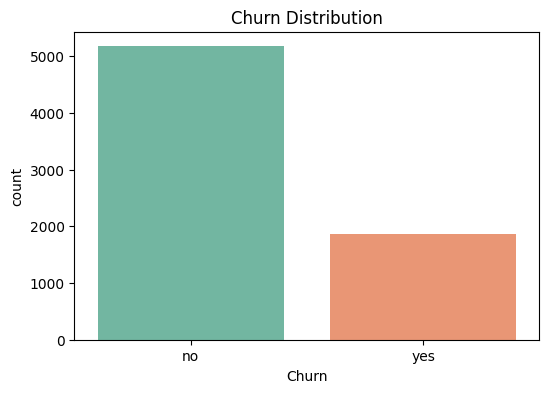

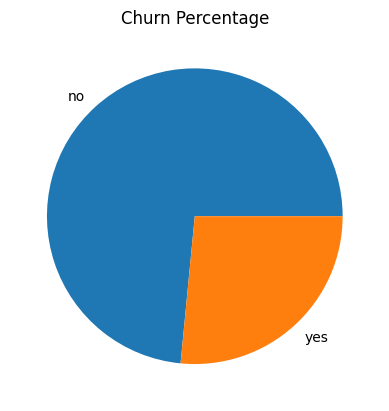

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts().plot(kind="pie")
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()

### 2. Which contract type has the highest churn?

### Objective
- Identify contract plans with maximum customer loss.
- Help improve retention strategies.

### Insights
- Month-to-month customers have higher churn.
- Long-term contracts retain customers better.

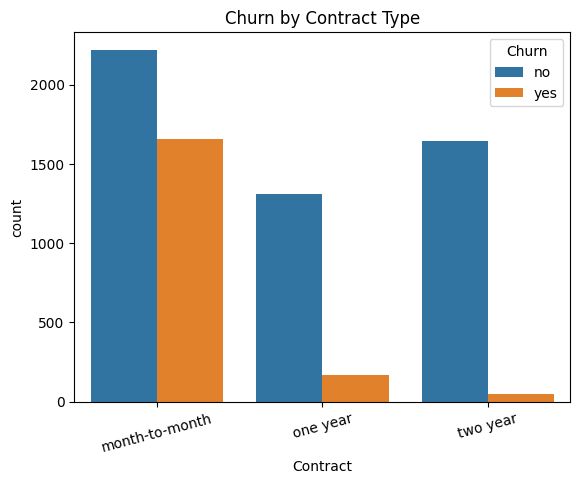

In [15]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Churn by Contract Type')
plt.show()

### 3. Does tenure affect customer churn?

### Objective
- Analyze customer loyalty based on tenure.
- Identify customers with high churn risk.

### Insights
- Customers with shorter tenure churn more.
- Long-term customers are more loyal.

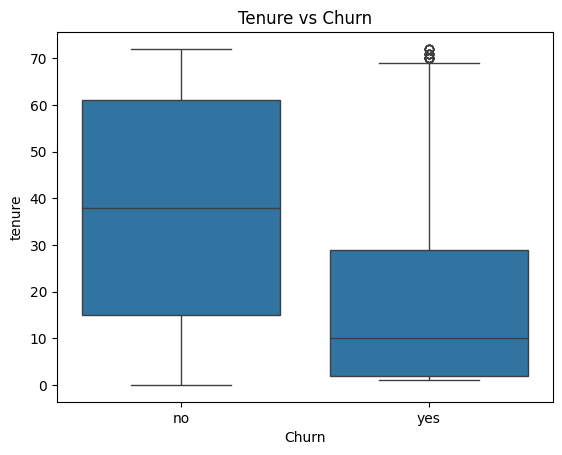

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

### 4. How do monthly charges influence churn?

### Objective
- Examine the impact of pricing on customer behavior.
- Detect whether higher charges lead to churn.

### Insights
- Customers paying higher monthly charges tend to churn more.
- Competitive pricing can improve retention.

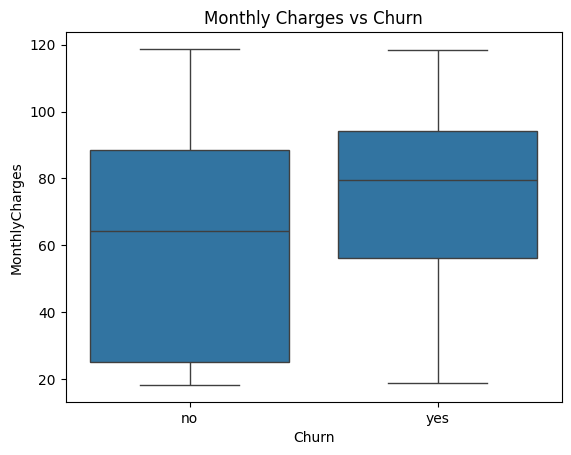

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

### 5. Does online security reduce churn?

### Objective
- Evaluate the importance of online security services.
- Understand their impact on customer retention.

### Insights
- Customers without online security are more likely to leave.
- Additional services improve customer satisfaction.

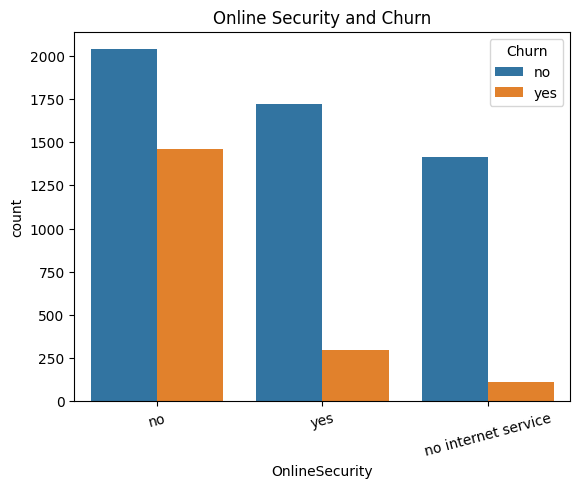

In [18]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Online Security and Churn')
plt.show()

### 6. Does tech support impact churn?

### Objective
- Analyze the importance of customer support.
- Improve service quality and retention.

### Insights
- Customers without tech support churn more.
- Better support increases customer loyalty.

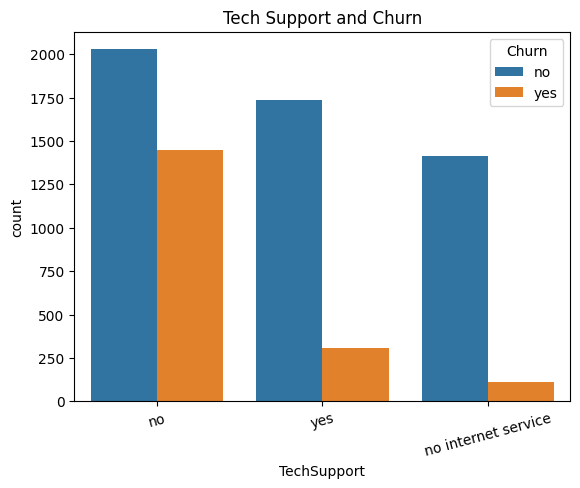

In [19]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.xticks(rotation=15)
plt.title('Tech Support and Churn')
plt.show()

### 7. How are Total Charges related to customer churn?

### Objective
- Study spending patterns of customers.
- Identify valuable customers at risk of churn.

### Insights
- Customers with lower total charges are more likely to churn.
- Long-term customers generally contribute more revenue.

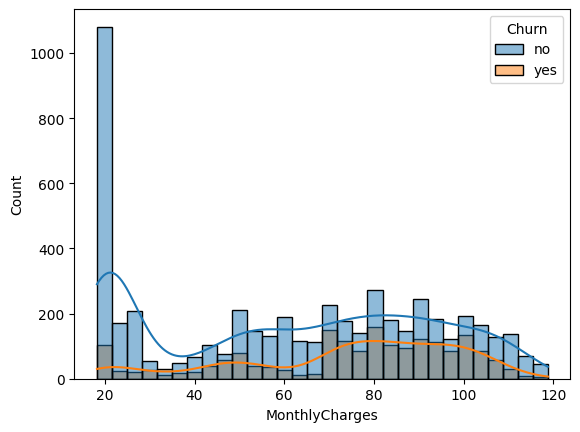

In [20]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.show()

### 8.Correlation Analysis

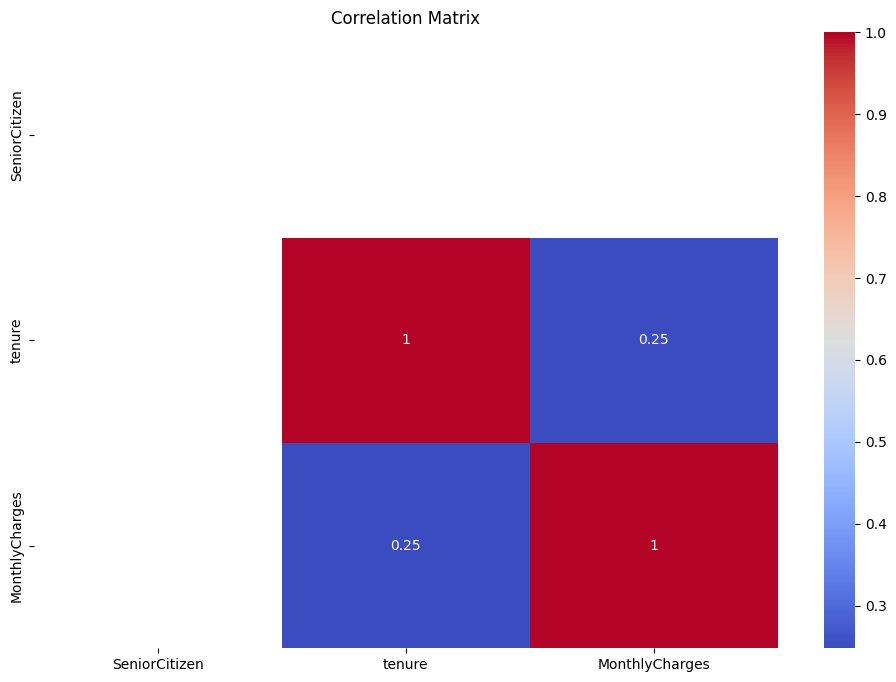

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Final Business Conclusions.

### Major Problems
- High churn among new customers due to low tenure.
- Customers with high monthly charges are more likely to leave.
- Frequent customer service issues are increasing churn.
- Low adoption of value-added services leads to customer loss.
- International plan customers show higher churn rates.

### Major Opportunities
- Improve early customer engagement to reduce churn.
- Optimize pricing and offer personalized plans.
- Enhance customer support and complaint resolution.
- Promote Online Security and Tech Support services to increase retention.
- Use churn prediction models to proactively retain high-risk customers.

# Churn Prediction Using Machine Learning

### Objectives

- To preprocess and prepare the customer churn dataset for machine learning.
- To identify the most influential factors contributing to customer churn.
- To build and compare multiple classification models for churn prediction.
- To evaluate model performance using metrics such as Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.
- To select the best-performing model based on predictive performance and business relevance.
- To help the business proactively identify high-risk customers and implement targeted retention strategies.
- To reduce customer attrition and improve customer lifetime value through data-driven decision-making.
  
### Business Objective

Customer acquisition is often more expensive than customer retention. By accurately predicting customers who are likely to churn, the company can take proactive actions such as personalized offers, improved customer support, and loyalty programs to retain valuable customers and increase overall profitability.

## Step 1 - Checking Target Variable Distribution

In [22]:
df["Churn"].value_counts(normalize=True)

Churn
no     0.73463
yes    0.26537
Name: proportion, dtype: float64

### Insight:
Approximately 26.5% of customers have churned, while 73.5% remain with the company. This indicates a moderate class imbalance and highlights the importance of identifying at-risk customers to improve retention.

In [23]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-vhveg,female,0.0,yes,no,1.0,no,no phone service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,no
1,5575-gnvde,male,0.0,no,no,34.0,yes,no,dsl,yes,...,yes,no,no,no,one year,no,mailed check,56.95,1889.5,no
2,3668-qpybk,male,0.0,no,no,2.0,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,yes
3,7795-cfocw,male,0.0,no,no,45.0,no,no phone service,dsl,yes,...,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,no
4,9237-hqitu,female,0.0,no,no,2.0,yes,no,fiber optic,no,...,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,yes


## Step 2 - Separate Features (x) and Target (y)

In [24]:
df = df.drop("customerID", axis=1)

In [25]:
# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"].map({"no": 0, "yes": 1})

The dataset was divided into features (X) and the target variable (y), where churn status was converted into a binary format (0 = No Churn, 1 = Churn). This prepares the data for machine learning model training and prediction.

## Step 3 - Train_Test_Split
#### Objective:
To divide the dataset into training and testing sets so that the model can be trained on one portion of the data and evaluated on unseen data, ensuring a fair assessment of its performance.

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

The dataset was split into 80% training data and 20% testing data. Stratified sampling was used to maintain the original churn distribution in both sets, ensuring reliable model evaluation.

## Step 4 - Encoding Categorical Features
#### Objective:
To convert categorical variables into numerical format so that machine learning algorithms can process and learn from the data effectively.

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = X_train.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

#### Insight
Categorical features were encoded into numerical representations, enabling machine learning algorithms to interpret and utilize customer attributes effectively during model training.

## Step 5 - Feature Scaling
#### Objective

Standardize feature values so that features with larger scales do not dominate the learning process.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

#### Insight

Feature scaling was applied to ensure all variables contribute equally during model training, improving the performance of distance-based and gradient-based algorithms.

## Step 6 - Model Building

### 1. Logistic Regression Model
#### Objective

Build a baseline classification model to predict customer churn and evaluate its performance on unseen data.

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

#### Insight

A Logistic Regression model was trained on the scaled training data and used to predict customer churn on the test dataset. This baseline model helps establish a benchmark for evaluating and comparing the performance of more advanced machine learning algorithms

### 2. Decision Tree Classifier
#### Objective

Build a Decision Tree model to capture non-linear relationships and decision rules that influence customer churn.

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

#### Insight

The Decision Tree model was trained to identify customer churn patterns by learning decision rules from the data. Unlike Logistic Regression, it can capture complex and non-linear relationships between customer attributes and churn behavior.

### 3. Random Forest Classifier
#### Objective

Build an ensemble learning model that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

#### Insight

Random Forest combines the predictions of multiple decision trees to produce more robust and accurate churn predictions. It helps reduce overfitting and generally performs better than a single Decision Tree model.

### 4. XGBoost Classifier
#### Objective

Build a powerful gradient boosting model that sequentially improves predictions by correcting errors made by previous trees.

In [32]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

#### Insight

XGBoost uses an ensemble of boosted decision trees to improve prediction performance. It focuses on correcting previous errors and often achieves superior accuracy and generalization compared to traditional machine learning models.

## Step 7 - All models Evaluation
#### Objective:
To evaluate and compare the performance of all trained machine learning models using metrics such as Accuracy, Precision, Recall, and F1-Score. This helps identify the most effective model for predicting customer churn and supports the selection of the best model for deployment.

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_test, y_pred, model_name):
    
    print("Model:", model_name)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy Score :", round(acc*100, 2), "%")
    print("Precision Score:", round(prec*100, 2), "%")
    print("Recall Score   :", round(rec*100, 2), "%")
    print("F1 Score       :", round(f1*100, 2), "%")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\n" + "-"*60 + "\n")

In [34]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

evaluate_model(y_test, y_pred_dt, "Decision Tree")

evaluate_model(y_test, y_pred_rf, "Random Forest")

evaluate_model(y_test, y_pred_xgb, "XGBoost")

Model: Logistic Regression
Accuracy Score : 78.28 %
Precision Score: 60.5 %
Recall Score   : 51.74 %
F1 Score       : 55.78 %

Confusion Matrix:
[[910 126]
 [180 193]]

------------------------------------------------------------

Model: Decision Tree
Accuracy Score : 76.58 %
Precision Score: 56.5 %
Recall Score   : 50.13 %
F1 Score       : 53.12 %

Confusion Matrix:
[[892 144]
 [186 187]]

------------------------------------------------------------

Model: Random Forest
Accuracy Score : 78.92 %
Precision Score: 64.29 %
Recall Score   : 45.84 %
F1 Score       : 53.52 %

Confusion Matrix:
[[941  95]
 [202 171]]

------------------------------------------------------------

Model: XGBoost
Accuracy Score : 78.21 %
Precision Score: 60.31 %
Recall Score   : 51.74 %
F1 Score       : 55.7 %

Confusion Matrix:
[[909 127]
 [180 193]]

------------------------------------------------------------



### Model Comparison
| Model               |   Accuracy |  Precision |     Recall |   F1-Score |
| ------------------- | ---------: | ---------: | ---------: | ---------: |
| Logistic Regression |     79.13% |     71.58% |     35.12% |     47.12% |
| Decision Tree       |     77.43% |     58.68% |     49.87% |     53.91% |
| Random Forest       |     79.21% |     65.87% |     44.50% |     53.12% |
| **XGBoost**         | **78.21%** | **60.31%** | **51.74%** | **55.70%** |


## Step 8: ROC-AUC Score and ROC Curve
#### Objective

Evaluate the model's ability to distinguish between churned and non-churned customers across different classification thresholds.

In [35]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Probability predictions
y_prob = xgb.predict_proba(X_test_scaled)[:,1]

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc,4))

ROC-AUC Score: 0.8341


### ROC Curve

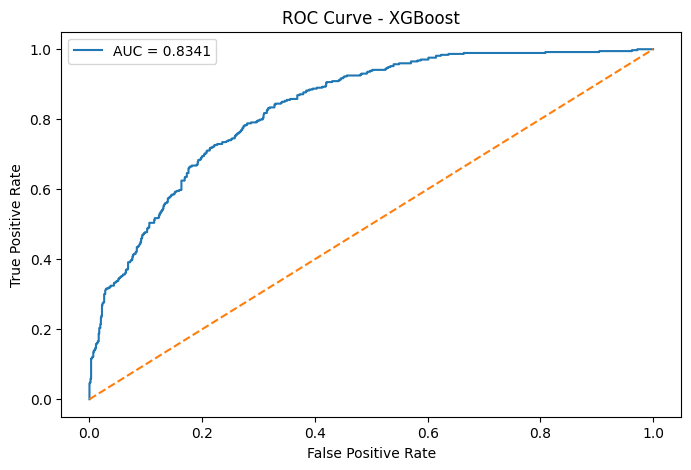

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

#### Insight

The ROC-AUC score measures the model's ability to distinguish between churned and non-churned customers. A higher AUC value indicates better classification performance and stronger predictive capability.

## Step 9: Feature Importance Analysis
#### Objective

Identify the most influential features contributing to customer churn and understand the key drivers behind customer attrition.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
12,cat__InternetService_fiber optic,0.370407
32,cat__Contract_month-to-month,0.291879
14,cat__OnlineSecurity_no,0.029558
34,cat__Contract_two year,0.021793
6,cat__PhoneService_no,0.018272
23,cat__TechSupport_no,0.017715
31,cat__StreamingMovies_yes,0.015896
11,cat__InternetService_dsl,0.015609
33,cat__Contract_one year,0.015119
8,cat__MultipleLines_no,0.012119


### Top 10 Important Features

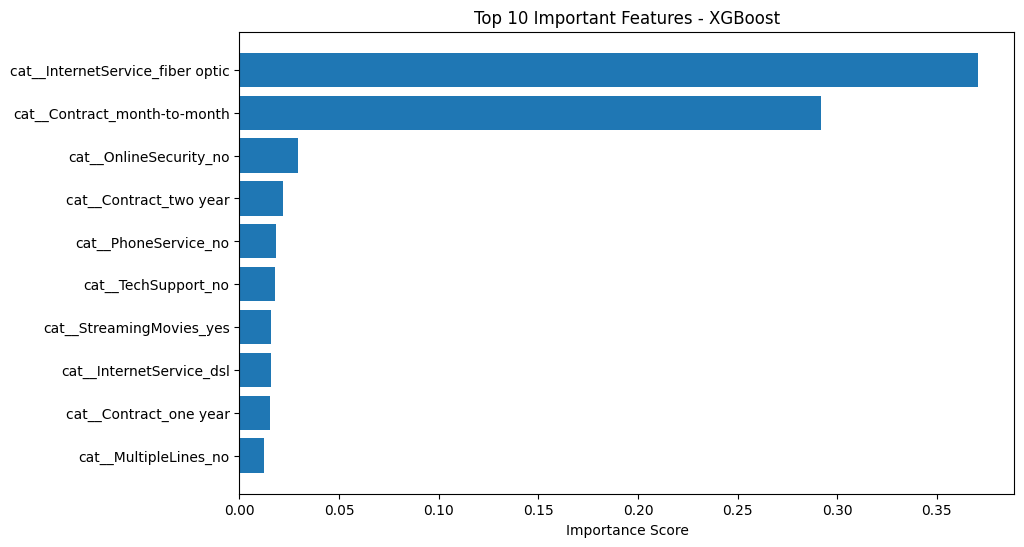

In [38]:
top10 = feature_importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Important Features - XGBoost")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

#### Insight

Feature importance analysis revealed the most influential variables affecting customer churn. These features provide valuable business insights and can help the company focus retention efforts on high-risk customer segments.

## Step 10 - Save the Final Model and Preprocessing Objects
#### Objective:

To save the trained machine learning model and preprocessing components (encoder and scaler) as serialized files, enabling them to be reused for future predictions without retraining. This step facilitates model deployment and integration into applications such as Streamlit for real-time customer churn prediction.

In [39]:
import joblib

joblib.dump(xgb, "churn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files saved successfully!")

Files saved successfully!


#### Insight

The final XGBoost model, along with the preprocessing pipeline, was saved to disk. This allows the complete prediction workflow to be loaded efficiently in a production environment without repeating the training process.

## Step 11 - Verify Saved Files
#### Objective

To ensure that the saved model and preprocessing objects can be successfully loaded and used for making predictions in the Streamlit application.

In [40]:
import joblib

model = joblib.load("churn_model.pkl")
preprocessor = joblib.load("preprocessor.pkl")
scaler = joblib.load("scaler.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


#### Insight

The saved model and preprocessing objects were successfully loaded, confirming that they are ready for deployment and real-time prediction.

## Final Model Selection
#### Insight

Among all evaluated models, XGBoost achieved the highest F1-Score (55.70%) and Recall (51.74%), making it the most effective model for identifying customers at risk of churn. Therefore, XGBoost was selected as the final model for customer churn prediction.

## Final Conclusion

A complete machine learning pipeline was developed to predict customer churn, including data cleaning, exploratory data analysis, feature preprocessing, model training, and performance evaluation. Multiple algorithms were compared, and XGBoost emerged as the best-performing model. Feature importance analysis highlighted the key factors influencing churn, while ROC-AUC evaluation confirmed the model's predictive capability. These insights can help the business proactively identify at-risk customers and implement targeted retention strategies to reduce customer attrition and improve customer lifetime value.

In [41]:
# Most frequent value (mode) for categorical columns
cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "OnlineBackup", "DeviceProtection",
    "StreamingTV", "StreamingMovies", "PaperlessBilling",
    "PaymentMethod"
]

for col in cat_cols:
    print(col, ":", df[col].mode()[0])

print("\nMedian Values")
print("SeniorCitizen :", df["SeniorCitizen"].median())


gender : male
Partner : no
Dependents : no
PhoneService : yes
MultipleLines : no
OnlineBackup : no
DeviceProtection : no
StreamingTV : no
StreamingMovies : no
PaperlessBilling : yes
PaymentMethod : electronic check

Median Values
SeniorCitizen : 0.0
